In [1]:
#@title **Importar biblioteca pandas** { vertical-output: true, form-width: "60%" }
!pip install --upgrade gspread gspread_dataframe
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from oauth2client.service_account import ServiceAccountCredentials

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#@title **Como acessar uma planilha gsheet**
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

In [5]:
# Substitua 'sheet_id' pelo ID da sua planilha
sheet_id = '1juXgcVZ9W4n6g1ztqhv3xCiSKgZm3loLF1L0s99kwaQ'
sheet_name = 'SINASC_2020_comp'  # Nome da aba específica dentro da planilha

sh = gc.open_by_key(sheet_id)
worksheet = sh.worksheet(sheet_name)

# Carregar os dados da planilha em um DataFrame do pandas
import pandas as pd
data = worksheet.get_all_records()
sinasc = pd.DataFrame(data)

# Exibir o DataFrame
sinasc.head()

,n,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,...,TPDOCRESP,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR
0,1,1,2552086,230640,1,34,1,4,NA,3,...,0,21022020,6,0,1,1,3,1,5,267059
1,2,1,2218690,313170,1,20,1,4,999992,0,...,0,NA,6,0,1,1,3,1,5,606117
2,3,1,3394514,230440,1,21,1,4,422310,0,...,3,4092020,12,0,1,1,11,0,5,1661732
3,4,1,2702983,260600,1,25,5,4,521110,0,...,4,30062020,6,0,1,1,3,1,5,355894
4,5,1,2748223,350750,1,31,2,5,521110,1,...,3,19062020,7,0,1,1,3,1,5,830956


In [6]:
print(sinasc.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 62 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   n           5000 non-null   int64 
 1   ORIGEM      5000 non-null   int64 
 2   CODESTAB    5000 non-null   object
 3   CODMUNNASC  5000 non-null   int64 
 4   LOCNASC     5000 non-null   int64 
 5   IDADEMAE    5000 non-null   int64 
 6   ESTCIVMAE   5000 non-null   object
 7   ESCMAE      5000 non-null   object
 8   CODOCUPMAE  5000 non-null   object
 9   QTDFILVIVO  5000 non-null   object
 10  QTDFILMORT  5000 non-null   object
 11  CODMUNRES   5000 non-null   int64 
 12  GESTACAO    5000 non-null   object
 13  GRAVIDEZ    5000 non-null   object
 14  PARTO       5000 non-null   object
 15  CONSULTAS   5000 non-null   int64 
 16  DTNASC      5000 non-null   int64 
 17  HORANASC    5000 non-null   object
 18  SEXO        5000 non-null   int64 
 19  APGAR1      5000 non-null   object
 20  APGAR5  

In [7]:
sinasc['ESTCIVMAE'] = sinasc['ESTCIVMAE'].astype('category')
sinasc['LOCNASC'] = sinasc['LOCNASC'].astype('category')
sinasc['PARTO'] = sinasc['PARTO'].astype('category')
sinasc['ESCMAE'] = sinasc['ESCMAE'].astype('category')

print('ESTCIVMAE:', sinasc['ESTCIVMAE'].dtypes)
print('ESCMAE:', sinasc['ESCMAE'].dtypes)

ESTCIVMAE: category
ESCMAE: category


**Aplicação do Teorema de Bayes**

Suponha que a probabilidade de o tempo estar nublado seja de 40%. A probabilidade de chuva em um determinado dia é de 20% e a probabilidade de nuvens em um dia chuvoso seja de 85%. Se estiver nublado lá fora em um determinado dia, qual é a probabilidade de chover nesse dia?


In [8]:
#@title **Resolução**

def probabilidade_chuva_dado_nublado():

    # Probabilidades dadas no problema
    P_N = 0.40          # P(Nublado)
    P_C = 0.20          # P(Chuva)
    P_N_dado_C = 0.85   # P(Nublado | Chuva)

    # Cálculo usando Teorema de Bayes:
    # P(C | N) = [P(N | C) * P(C)] / P(N)


    P_C_dado_N = P_N_dado_C * P_C/P_N

    # Exibição dos resultados
    print("=== Cálculo da Probabilidade de Chuva Dado Nublado ===")
    print(f"Probabilidade de estar nublado (P(N))          : {P_N:.2%}")
    print(f"Probabilidade de chuva (P(C))                  : {P_C:.2%}")
    print(f"Probabilidade de nublado dado chuva (P(N|C))   : {P_N_dado_C:.2%}")
    print("-" * 55)
    print(f"Probabilidade de chover se estiver nublado:")
    print(f"P(C | N) = {P_C_dado_N:.4f} ou {P_C_dado_N:.2%}")

    return P_C_dado_N


if __name__ == "__main__":
    resultado = probabilidade_chuva_dado_nublado()

=== Cálculo da Probabilidade de Chuva Dado Nublado ===
Probabilidade de estar nublado (P(N))          : 40.00%
Probabilidade de chuva (P(C))                  : 20.00%
Probabilidade de nublado dado chuva (P(N|C))   : 85.00%
-------------------------------------------------------
Probabilidade de chover se estiver nublado:
P(C | N) = 0.4250 ou 42.50%


In [9]:
#@title **Aplicação do Teorema de Bayes - calculando a probabilidade a partir da frequência em um dataframe**
import pandas as pd

bayes = pd.read_csv ('/content/drive/MyDrive/Colab Notebooks/naive_bayes_dataset.csv')
print (bayes)

   id     age  income student credit_rating buys_computer
0   1   youth     low      no          fair           yes
1   2   youth    high     yes     excellent            no
2   3   youth    high      no          fair           yes
3   4  middle  medium     yes          fair           yes
4   5  senior     low     yes          fair           yes
5   6  senior     low     yes     excellent           yes
6   7  middle    high     yes     excellent           yes
7   8   youth  medium      no          fair            no
8   9  middle     low      no     excellent           yes
9  10  senior  medium     yes          fair           yes


In [10]:
 #@title Calcular a probabilidade a priori de Buys computer - P(Buys computer)
prior = bayes.groupby('buys_computer').size().div(len(bayes))
print (prior)

buys_computer
no     0.2
yes    0.8
dtype: float64


**Calculando a probabilidade**

A probabilidade é gerada para cada um dos recursos do conjunto de dados. Basicamente, a probabilidade é a probabilidade de encontrar cada recurso dado o rótulo de classe.


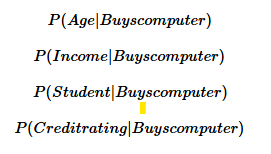

In [ ]:
prob = {}
prob['credit_rating'] = data.groupby(['buys_computer', 'credit_rating']).size().div(len(data)).div(prior)
prob['age'] = data.groupby(['buys_computer', 'age']).size().div(len(data)).div(prior)
prob['income'] = data.groupby(['buys_computer', 'income']).size().div(len(data)).div(prior)
prob['student'] = data.groupby(['buys_computer', 'student']).size().div(len(data)).div(prior)

print (prob)

{'credit_rating': buys_computer  credit_rating
no             excellent        0.500
               fair             0.500
yes            excellent        0.375
               fair             0.625
dtype: float64, 'age': buys_computer  age   
no             youth     1.000
yes            middle    0.375
               senior    0.375
               youth     0.250
dtype: float64, 'income': buys_computer  income
no             high      0.50
               medium    0.50
yes            high      0.25
               low       0.50
               medium    0.25
dtype: float64, 'student': buys_computer  student
no             no         0.500
               yes        0.500
yes            no         0.375
               yes        0.625
dtype: float64}


**Calculando a posteriori**

Precisamos saber se uma pessoa comprará um computador dado que ele seja jovem

Substituindo os valores nos dados de verossimilhança e na fórmula de Bayes, obtemos
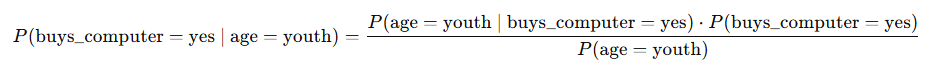

In [ ]:

# Contagem total de registros
total_count = len(bayes)

# Contagem para 'buys_computer = yes'
buys_computer_yes_count = len(bayes[bayes['buys_computer'] == 'yes'])

# Contagem para 'age = youth' e 'buys_computer = yes'
age_youth_and_buys_computer_yes_count = len(bayes[(bayes['age'] == 'youth') & (bayes['buys_computer'] == 'yes')])

# Contagem para 'age = youth'
age_youth_count = len(bayes[bayes['age'] == 'youth'])

# Probabilidades
P_buys_computer_yes = buys_computer_yes_count / total_count
P_age_youth_given_buys_computer_yes = age_youth_and_buys_computer_yes_count / buys_computer_yes_count
P_age_youth = age_youth_count / total_count

# Cálculo usando o Teorema de Bayes
P_buys_computer_yes_given_age_youth = (P_age_youth_given_buys_computer_yes * P_buys_computer_yes) / P_age_youth
print("P(buys_computer = yes | age = youth):", P_buys_computer_yes_given_age_youth)

P(buys_computer = yes | age = youth): 0.5


**Exercícios**

1. Fazer os exercícios que estão no pdf "na unha" e em python